Title: vars_dist_comp.ipynb

Purpose: Plot the variable distributions for current and future climate

Author: Onno Nennecke on 02.06.2025 Modified: 23.07.2026

Input data: 

- Mean variable datasets

Output data:

- Some plots to compare

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
import os
from matplotlib.patches import Patch
import matplotlib as mpl

In [2]:
# Read datasets
esm_ds_cur_tas = xr.open_dataset(f'/climca/people/onennecke/model_output/var_means_masked/winter_data_condensed/tas_sp_mean_mask_ex_ws_cur.nc')
esm_ds_fut_tas = xr.open_dataset(f'/climca/people/onennecke/model_output/var_means_masked/winter_data_condensed/tas_sp_mean_mask_ex_ws_fut.nc')
esm_ds_cur_sfcWind = xr.open_dataset(f'/climca/people/onennecke/model_output/var_means_masked/winter_data_condensed/sfcWind_sp_mean_mask_ex_ws_cur.nc')
esm_ds_fut_sfcWind = xr.open_dataset(f'/climca/people/onennecke/model_output/var_means_masked/winter_data_condensed/sfcWind_sp_mean_mask_ex_ws_fut.nc')
esm_ds_cur_rsds = xr.open_dataset(f'/climca/people/onennecke/model_output/var_means_masked/winter_data_condensed/rsds_sp_mean_mask_ex_ws_cur.nc')
esm_ds_fut_rsds = xr.open_dataset(f'/climca/people/onennecke/model_output/var_means_masked/winter_data_condensed/rsds_sp_mean_mask_ex_ws_fut.nc')

datasets = {
    'tas': (esm_ds_cur_tas, esm_ds_fut_tas),
    'sfcWind': (esm_ds_cur_sfcWind, esm_ds_fut_sfcWind),
    'rsds': (esm_ds_cur_rsds, esm_ds_fut_rsds)
}

In [3]:

# ── Config ────────────────────────────────────────────────────────────────────
datasets = {
    'tas':      (esm_ds_cur_tas,      esm_ds_fut_tas),
    'sfcWind':  (esm_ds_cur_sfcWind,  esm_ds_fut_sfcWind),
    'rsds':     (esm_ds_cur_rsds,     esm_ds_fut_rsds),
}
var_labels = {'tas': 'Temperature (K)', 'sfcWind': 'Wind speed (m/s)', 'rsds': 'Radiation (W/m²)'}
panel_labels = ['(a)', '(b)', '(c)']

# ── Helper: build per-ESM data dicts and summary df ───────────────────────────
def build_dicts_and_summary(esm_ds_cur, esm_ds_fut, variable_name):
    cur_dict, fut_dict = {}, {}

    # All ESMs pooled
    cur_all = esm_ds_cur[variable_name].values.ravel()
    cur_all = cur_all[~np.isnan(cur_all)]
    fut_all = esm_ds_fut[variable_name].values.ravel()
    fut_all = fut_all[~np.isnan(fut_all)]
    cur_dict['All ESMs'] = cur_all
    fut_dict['All ESMs'] = fut_all

    # Per ESM
    for esm in np.unique(esm_ds_cur.ESM.values):
        cur = esm_ds_cur.where(esm_ds_cur.ESM == esm)[variable_name].values.ravel()
        fut = esm_ds_fut.where(esm_ds_fut.ESM == esm)[variable_name].values.ravel()
        cur_dict[esm] = cur[~np.isnan(cur)]
        fut_dict[esm] = fut[~np.isnan(fut)]

    # Summary statistics
    rows = []
    for esm, cur in cur_dict.items():
        fut = fut_dict[esm]
        ks_stat, ks_p = ks_2samp(cur, fut)
        # rows.append({
        #     'ESM':          esm,
        #     'Current Mean': np.mean(cur),
        #     'Future Mean':  np.mean(fut),
        #     'Delta Mean':   np.mean(fut) - np.mean(cur),
        #     'Delta Mean (%)': (np.mean(fut) - np.mean(cur)) / np.mean(cur) * 100,
        #     'Current Std':  np.std(cur),
        #     'Future Std':   np.std(fut),
        #     'Delta Std':    np.std(fut) - np.std(cur),
        #     'Delta Std (%)': (np.std(fut) - np.std(cur)) / np.std(cur) * 100,
        #     'KS Statistic': ks_stat,
        #     'KS p-value':   ks_p,
        # })
        if esm != 'ERA5':
            rows.append({
                'ESM':          esm,
                'Current Mean': np.mean(cur),
                'Future Mean':  np.mean(fut),
                'Delta Mean':   np.mean(fut) - np.mean(cur),
                'Delta Mean (%)': (np.mean(fut) - np.mean(cur)) / np.mean(cur) * 100,
                'Current Std':  np.std(cur),
                'Future Std':   np.std(fut),
                'Delta Std':    np.std(fut) - np.std(cur),
                'Delta Std (%)': (np.std(fut) - np.std(cur)) / np.std(cur) * 100,
                '5pctl Current': np.percentile(cur, 5),
                '5pctl Future':  np.percentile(fut, 5),
                'Delta 5pctl': np.percentile(fut, 5) - np.percentile(cur, 5),
                'Delta 5pctl (%)': (np.percentile(fut, 5) - np.percentile(cur, 5)) / np.percentile(cur, 5) * 100,
                '95pctl Current': np.percentile(cur, 95),
                '95pctl Future':  np.percentile(fut, 95),
                'Delta 95pctl': np.percentile(fut, 95) - np.percentile(cur, 95),
                'Delta 95pctl (%)': (np.percentile(fut, 95) - np.percentile(cur, 95)) / np.percentile(cur, 95) * 100,
                'KS Statistic': ks_stat,
                'KS p-value':   ks_p,
            })
        if esm == 'ERA5':
            rows.append({
                'ESM':          esm,
                'Current Mean': np.mean(cur),
                'Future Mean':  np.nan,
                'Delta Mean':   np.nan,
                'Delta Mean (%)': np.nan,
                'Current Std':  np.std(cur),
                'Future Std':   np.nan,
                'Delta Std':    np.nan,
                'Delta Std (%)': np.nan,
                '5pctl Current': np.percentile(cur, 5),
                '5pctl Future':  np.nan,
                'Delta 5pctl': np.nan,
                'Delta 5pctl (%)': np.nan,
                '95pctl Current': np.percentile(cur, 95),
                '95pctl Future':  np.nan,
                'Delta 95pctl': np.nan,
                'Delta 95pctl (%)': np.nan,
                'KS Statistic': np.nan,
                'KS p-value':   np.nan
            })

    df = pd.DataFrame(rows)

    # Change position of the All (weighted) row to the top
    df = pd.concat([df[df['ESM'] == 'All (weighted)'], df[df['ESM'] != 'All (weighted)']], ignore_index=True)
    # Change the position of ERA5 to the top of the dataframe
    df = pd.concat([df[df['ESM'] == 'ERA5'], df[df['ESM'] != 'ERA5']], ignore_index=True)
    return cur_dict, fut_dict, df




In [7]:
cur_dict, fut_dict, summary_df = build_dicts_and_summary(
        esm_ds_cur_tas, esm_ds_fut_tas, 'tas'
    )
summary_df

/tmp/ipykernel_2519387/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


,ESM,Current Mean,Future Mean,Delta Mean,Delta Mean (%),Current Std,Future Std,Delta Std,Delta Std (%),5pctl Current,5pctl Future,Delta 5pctl,Delta 5pctl (%),95pctl Current,95pctl Future,Delta 95pctl,Delta 95pctl (%),KS Statistic,KS p-value
0,ERA5,5.108118,NaN,NaN,NaN,4.201969,NaN,NaN,NaN,-1.497478,NaN,NaN,NaN,12.500389,NaN,NaN,NaN,NaN,NaN
1,All ESMs,5.336105,6.159636,0.823531,15.433189,4.592158,4.505952,-0.086206,-1.877243,-2.224365,-1.152780,1.071585,-48.174881,13.065860,13.877503,0.811644,6.211942,0.075254,0.000000e+00
2,ACCESS-CM2,3.652143,4.838500,1.186357,32.483856,4.233135,4.149608,-0.083527,-1.973173,-2.996545,-1.531805,1.464740,-48.880951,11.174639,12.461083,1.286445,11.512181,0.111355,6.905296e-30
3,BCC-CSM2-M,4.574496,5.826786,1.252290,27.375481,4.418561,4.317048,-0.101513,-2.297431,-2.579046,-0.838849,1.740198,-67.474457,11.826540,13.382326,1.555786,13.155040,0.127473,2.666323e-13
4,CESM2,6.460583,7.199090,0.738508,11.430977,4.139094,4.053497,-0.085597,-2.068014,-0.176469,0.787596,0.964065,-546.307556,13.759830,14.470444,0.710613,5.164404,0.073552,0.000000e+00
5,EC-Earth3,4.019309,4.958106,0.938797,23.357162,4.766663,4.704490,-0.062173,-1.304337,-4.083025,-2.830026,1.252998,-30.687994,11.943920,12.915286,0.971366,8.132723,0.085246,4.025344e-311
6,GFDL-ESM4,3.609792,4.375816,0.766024,21.220728,4.568510,4.422585,-0.145925,-3.194139,-3.619380,-3.167467,0.451914,-12.485938,11.362820,11.640120,0.277300,2.440414,0.098352,4.416067e-08
7,KACE-1-0-G,3.895496,5.185416,1.289920,33.113110,4.854356,4.837655,-0.016701,-0.344046,-3.980356,-2.300266,1.680090,-42.209549,12.708899,14.042704,1.333804,10.495041,0.111905,3.524602e-30
8,MPI-ESM1-2,3.633708,4.510311,0.876602,24.124174,4.628070,4.608038,-0.020031,-0.432825,-4.296361,-2.904170,1.392191,-32.403954,11.449360,12.515520,1.066160,9.311964,0.073022,1.213858e-42
9,MRI-ESM2-0,5.752363,6.189728,0.437365,7.603224,4.160415,4.226152,0.065737,1.580065,-0.934518,-0.443051,0.491467,-52.590443,12.821324,13.712618,0.891294,6.951650,0.038242,3.313523e-06


In [9]:
cur_dict, fut_dict, summary_df = build_dicts_and_summary(
        esm_ds_cur_sfcWind, esm_ds_fut_sfcWind, 'sfcWind'
    )
summary_df

/tmp/ipykernel_2519387/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


,ESM,Current Mean,Future Mean,Delta Mean,Delta Mean (%),Current Std,Future Std,Delta Std,Delta Std (%),5pctl Current,5pctl Future,Delta 5pctl,Delta 5pctl (%),95pctl Current,95pctl Future,Delta 95pctl,Delta 95pctl (%),KS Statistic,KS p-value
0,ERA5,6.338730,NaN,NaN,NaN,2.312808,NaN,NaN,NaN,3.125539,NaN,NaN,NaN,10.726143,NaN,NaN,NaN,NaN,NaN
1,All ESMs,5.767180,5.769924,0.002744,0.047579,2.164288,2.188673,0.024385,1.126690,2.869164,2.850587,-0.018577,-0.647477,9.847001,9.881217,0.034216,0.347476,0.003676,1.755143e-02
2,ACCESS-CM2,5.732692,5.675693,-0.056999,-0.994285,2.162642,2.181980,0.019337,0.894144,2.802017,2.725453,-0.076564,-2.732472,9.790804,9.740979,-0.049824,-0.508888,0.016484,4.484190e-01
3,BCC-CSM2-M,6.588217,6.809249,0.221032,3.354961,1.930841,1.983183,0.052342,2.710820,3.689633,3.848780,0.159147,4.313360,10.064649,10.256272,0.191624,1.903929,0.057143,5.240631e-03
4,CESM2,5.197128,5.225565,0.028437,0.547166,1.827644,1.847997,0.020352,1.113573,2.657966,2.649896,-0.008070,-0.303631,8.563574,8.638725,0.075152,0.877572,0.009517,8.409774e-08
5,EC-Earth3,6.688601,6.688903,0.000302,0.004511,2.364467,2.432685,0.068218,2.885126,3.632865,3.578762,-0.054103,-1.489262,11.250648,11.428323,0.177675,1.579247,0.012352,6.090179e-07
6,GFDL-ESM4,7.048868,6.863641,-0.185227,-2.627754,2.368235,2.325655,-0.042580,-1.797965,3.670536,3.512784,-0.157752,-4.297794,11.249069,10.965396,-0.283673,-2.521750,0.045055,4.970705e-02
7,KACE-1-0-G,6.786740,6.862891,0.076151,1.122050,2.193910,2.176749,-0.017162,-0.782244,3.704896,3.771143,0.066247,1.788084,10.860848,10.760322,-0.100525,-0.925576,0.022527,1.251857e-01
8,MPI-ESM1-2,6.308161,6.246894,-0.061267,-0.971230,2.354647,2.343792,-0.010854,-0.460979,3.075879,3.026118,-0.049761,-1.617776,10.743666,10.615130,-0.128536,-1.196392,0.015440,2.584110e-02
9,MRI-ESM2-0,5.712453,5.700541,-0.011913,-0.208537,1.921120,1.941423,0.020303,1.056833,2.991480,2.989903,-0.001577,-0.052701,9.238886,9.264363,0.025477,0.275758,0.013736,3.571315e-01


In [10]:
cur_dict, fut_dict, summary_df = build_dicts_and_summary(
        esm_ds_cur_rsds, esm_ds_fut_rsds, 'rsds'
    )
summary_df

/tmp/ipykernel_2519387/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


,ESM,Current Mean,Future Mean,Delta Mean,Delta Mean (%),Current Std,Future Std,Delta Std,Delta Std (%),5pctl Current,5pctl Future,Delta 5pctl,Delta 5pctl (%),95pctl Current,95pctl Future,Delta 95pctl,Delta 95pctl (%),KS Statistic,KS p-value
0,ERA5,59.991802,NaN,NaN,NaN,39.412170,NaN,NaN,NaN,18.084637,NaN,NaN,NaN,139.092743,NaN,NaN,NaN,NaN,NaN
1,All ESMs,59.937614,60.038364,0.100750,0.168091,39.699478,39.875904,0.176426,0.444404,16.849949,16.903240,0.053291,0.316270,140.456345,141.321335,0.864990,0.615843,0.001990,0.491045
2,ACCESS-CM2,53.642239,54.611099,0.968861,1.806152,33.390251,34.827221,1.436970,4.303561,16.813540,17.158382,0.344843,2.050983,120.331963,124.514290,4.182327,3.475658,0.014286,0.633243
3,BCC-CSM2-M,47.889801,48.132973,0.243172,0.507773,37.043804,38.929161,1.885357,5.089534,9.822356,9.500990,-0.321366,-3.271784,126.478867,130.395203,3.916336,3.096435,0.026374,0.551456
4,CESM2,60.037201,60.343315,0.306114,0.509874,41.393063,41.598270,0.205208,0.495754,15.873830,16.103891,0.230062,1.449313,145.220047,146.286148,1.066101,0.734128,0.004321,0.060222
5,EC-Earth3,61.604763,61.046139,-0.558624,-0.906787,37.477749,37.444424,-0.033325,-0.088920,19.900827,19.540108,-0.360720,-1.812586,136.333420,136.171036,-0.162384,-0.119108,0.010226,0.000068
6,GFDL-ESM4,54.001675,54.662041,0.660366,1.222862,34.764797,37.167549,2.402752,6.911450,14.947686,15.330931,0.383245,2.563905,123.163948,127.531166,4.367218,3.545858,0.034066,0.241585
7,KACE-1-0-G,57.115280,58.101593,0.986313,1.726881,37.018215,38.308392,1.290176,3.485248,17.090977,16.757141,-0.333836,-1.953286,131.427246,136.643494,5.216248,3.968924,0.017582,0.367500
8,MPI-ESM1-2,51.144432,51.218811,0.074379,0.145429,35.672249,36.054764,0.382515,1.072304,13.798655,13.707562,-0.091092,-0.660152,124.856094,124.971375,0.115280,0.092330,0.011923,0.149189
9,MRI-ESM2-0,63.438206,64.457695,1.019489,1.607059,40.633007,40.351837,-0.281170,-0.691974,19.112482,19.576185,0.463703,2.426180,147.424255,145.828384,-1.595871,-1.082502,0.020659,0.041136


/tmp/ipykernel_2519387/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)
/tmp/ipykernel_2519387/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


Variable: sfcWind


/tmp/ipykernel_2519387/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


Variable: rsds


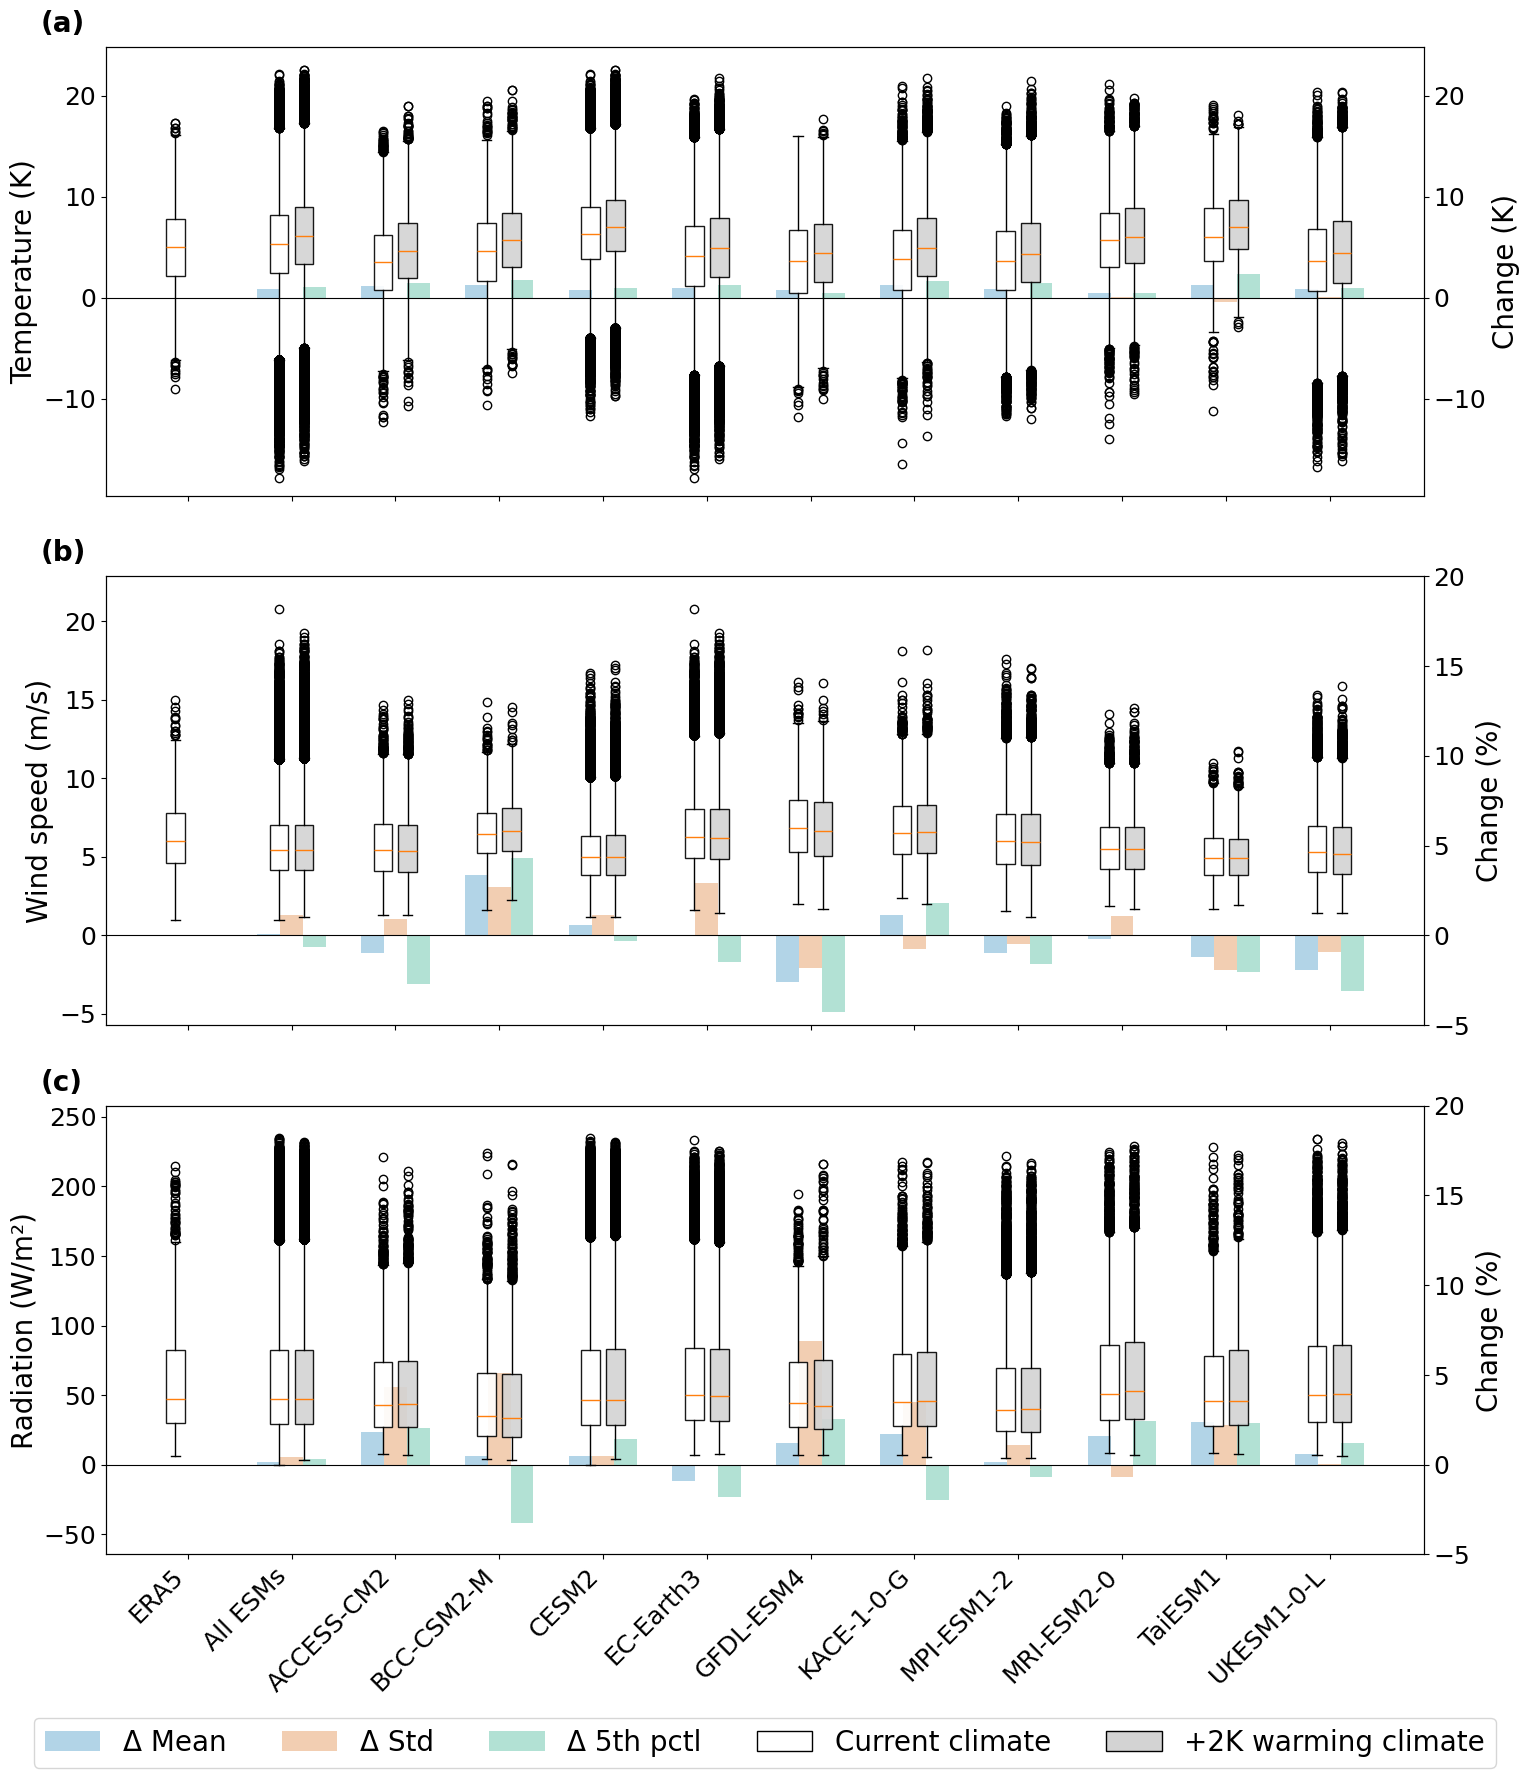

In [4]:
mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
})

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# Fixed secondary-axis range for the % panels (b) and (c)
PCT_YMIN, PCT_YMAX = -5, 20
zero_frac_below = -PCT_YMIN / (PCT_YMAX - PCT_YMIN)  # fraction of range below 0
zero_frac_above =  PCT_YMAX / (PCT_YMAX - PCT_YMIN)  # fraction of range above 0

for ax_box, (variable_name, (esm_ds_cur, esm_ds_fut)), panel in zip(
    axes, datasets.items(), panel_labels
):
    cur_dict, fut_dict, summary_df = build_dicts_and_summary(
        esm_ds_cur, esm_ds_fut, variable_name
    )

    esms = summary_df['ESM'].values
    if variable_name != 'tas':
        print(f"Variable: {variable_name}")
        delta_mean   = summary_df['Delta Mean (%)'].values
        delta_Std    = summary_df['Delta Std (%)'].values
        delta_5pctl  = summary_df['Delta 5pctl (%)'].values
    else:
        delta_mean   = summary_df['Delta Mean'].values
        delta_Std    = summary_df['Delta Std'].values
        delta_5pctl  = summary_df['Delta 5pctl'].values
    n = len(esms)
    x = np.arange(n)

    current_data = [cur_dict[k] for k in esms]
    future_data  = [fut_dict[k] for k in esms]

    ax_bar = ax_box.twinx()

    # ── Bars ──────────────────────────────────────────────────────────────────
    bar_width = 0.22
    ax_bar.bar(x - bar_width, delta_mean,  width=bar_width,
               color='#0072B2',   alpha=0.30, label='Δ Mean',  zorder=1)
    ax_bar.bar(x,              delta_Std,  width=bar_width,
               color='#D55E00',    alpha=0.30, label='Δ Std',   zorder=1)
    ax_bar.bar(x + bar_width,  delta_5pctl, width=bar_width,
               color='#009E73',  alpha=0.30, label='Δ 5th pctl', zorder=1)

    # ── Boxplots ──────────────────────────────────────────────────────────────
    offset = 0.12
    bp1 = ax_box.boxplot(current_data, positions=x - offset, widths=0.18,
                         patch_artist=True, manage_ticks=False,
                         showfliers=True, zorder=3)
    bp2 = ax_box.boxplot(future_data,  positions=x + offset, widths=0.18,
                         patch_artist=True, manage_ticks=False,
                         showfliers=True, zorder=3)

    for box in bp1['boxes']:
        box.set(facecolor='white',     edgecolor='black', alpha=0.9)
    for box in bp2['boxes']:
        box.set(facecolor='lightgray', edgecolor='black', alpha=0.9)

    # ── Axis limits ─────────────────────────────────────────────────────────
    all_vals = np.concatenate([np.concatenate(current_data),
                               np.concatenate(future_data)])

    if variable_name != 'tas':
        # Fixed % range on the bar axis
        ax_bar.set_ylim(PCT_YMIN, PCT_YMAX)

        # Match the box axis so its zero sits at the same fraction as the bar axis's zero
        vmin = np.nanmin(all_vals)
        vmax = np.nanmax(all_vals)
        R_from_min = (-vmin) / zero_frac_below if vmin < 0 else 0
        R_from_max = vmax / zero_frac_above if vmax > 0 else 0
        R = 1.1 * max(R_from_min, R_from_max)

        box_ymin = -R * zero_frac_below
        box_ymax =  R * zero_frac_above
        ax_box.set_ylim(box_ymin, box_ymax)
    else:
        # Panel (a): keep original symmetric behavior (absolute K units)
        vmin = np.nanmin(np.concatenate([all_vals, delta_mean, delta_Std, delta_5pctl]))
        vmax = np.nanmax(np.concatenate([np.abs(all_vals), np.abs(delta_mean),
                                          np.abs(delta_Std), np.abs(delta_5pctl)]))
        ax_box.set_ylim(1.1 * vmin, 1.1 * vmax)
        ax_bar.set_ylim(1.1 * vmin, 1.1 * vmax)

    ax_box.axhline(0, color='black', linewidth=0.8, zorder=2)

    # ── Labels ────────────────────────────────────────────────────────────────
    ax_box.set_ylabel(var_labels[variable_name])
    if variable_name != 'tas':
        ax_bar.set_ylabel('Change (%)')
    else:
        ax_bar.set_ylabel('Change (K)')

    if variable_name == 'rsds':
        ax_box.set_xticks(x)
        ax_box.set_xticklabels(esms, rotation=45, ha='right')
    else:
        ax_box.set_xticks(x)
        ax_box.set_xticklabels("", rotation=45, ha='right')

    ax_box.set_zorder(2)
    ax_bar.set_zorder(1)
    ax_box.patch.set_alpha(0)

    ax_box.text(-0.05, 1.02, panel, transform=ax_box.transAxes,
                fontsize=20, fontweight='bold', va='bottom')

    legend_elements = [
        Patch(facecolor='#0072B2',  alpha=0.30, label='Δ Mean'),
        Patch(facecolor='#D55E00',   alpha=0.30, label='Δ Std'),
        Patch(facecolor='#009E73', alpha=0.30, label='Δ 5th pctl'),
        Patch(facecolor='white',     edgecolor='black', label='Current climate'),
        Patch(facecolor='lightgray', edgecolor='black', label='+2K warming climate'),
    ]
    if variable_name == 'rsds':
        ax_box.legend(handles=legend_elements, ncol=5, loc='center',
                      bbox_to_anchor=(0.5, -0.42), bbox_transform=ax_box.transAxes)

# plt.suptitle('Current and Future Distributions with Change in Mean and Standard Deviation', y=0.98)
plt.tight_layout()
# plt.savefig('/home/onennecke/Code/Figures/vars_dist_comp.png', dpi=300, bbox_inches='tight')
plt.show()

## Old plots only std or 5 pctl old second y axis

/tmp/ipykernel_902818/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)
/tmp/ipykernel_902818/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


Variable: sfcWind


/tmp/ipykernel_902818/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


Variable: rsds


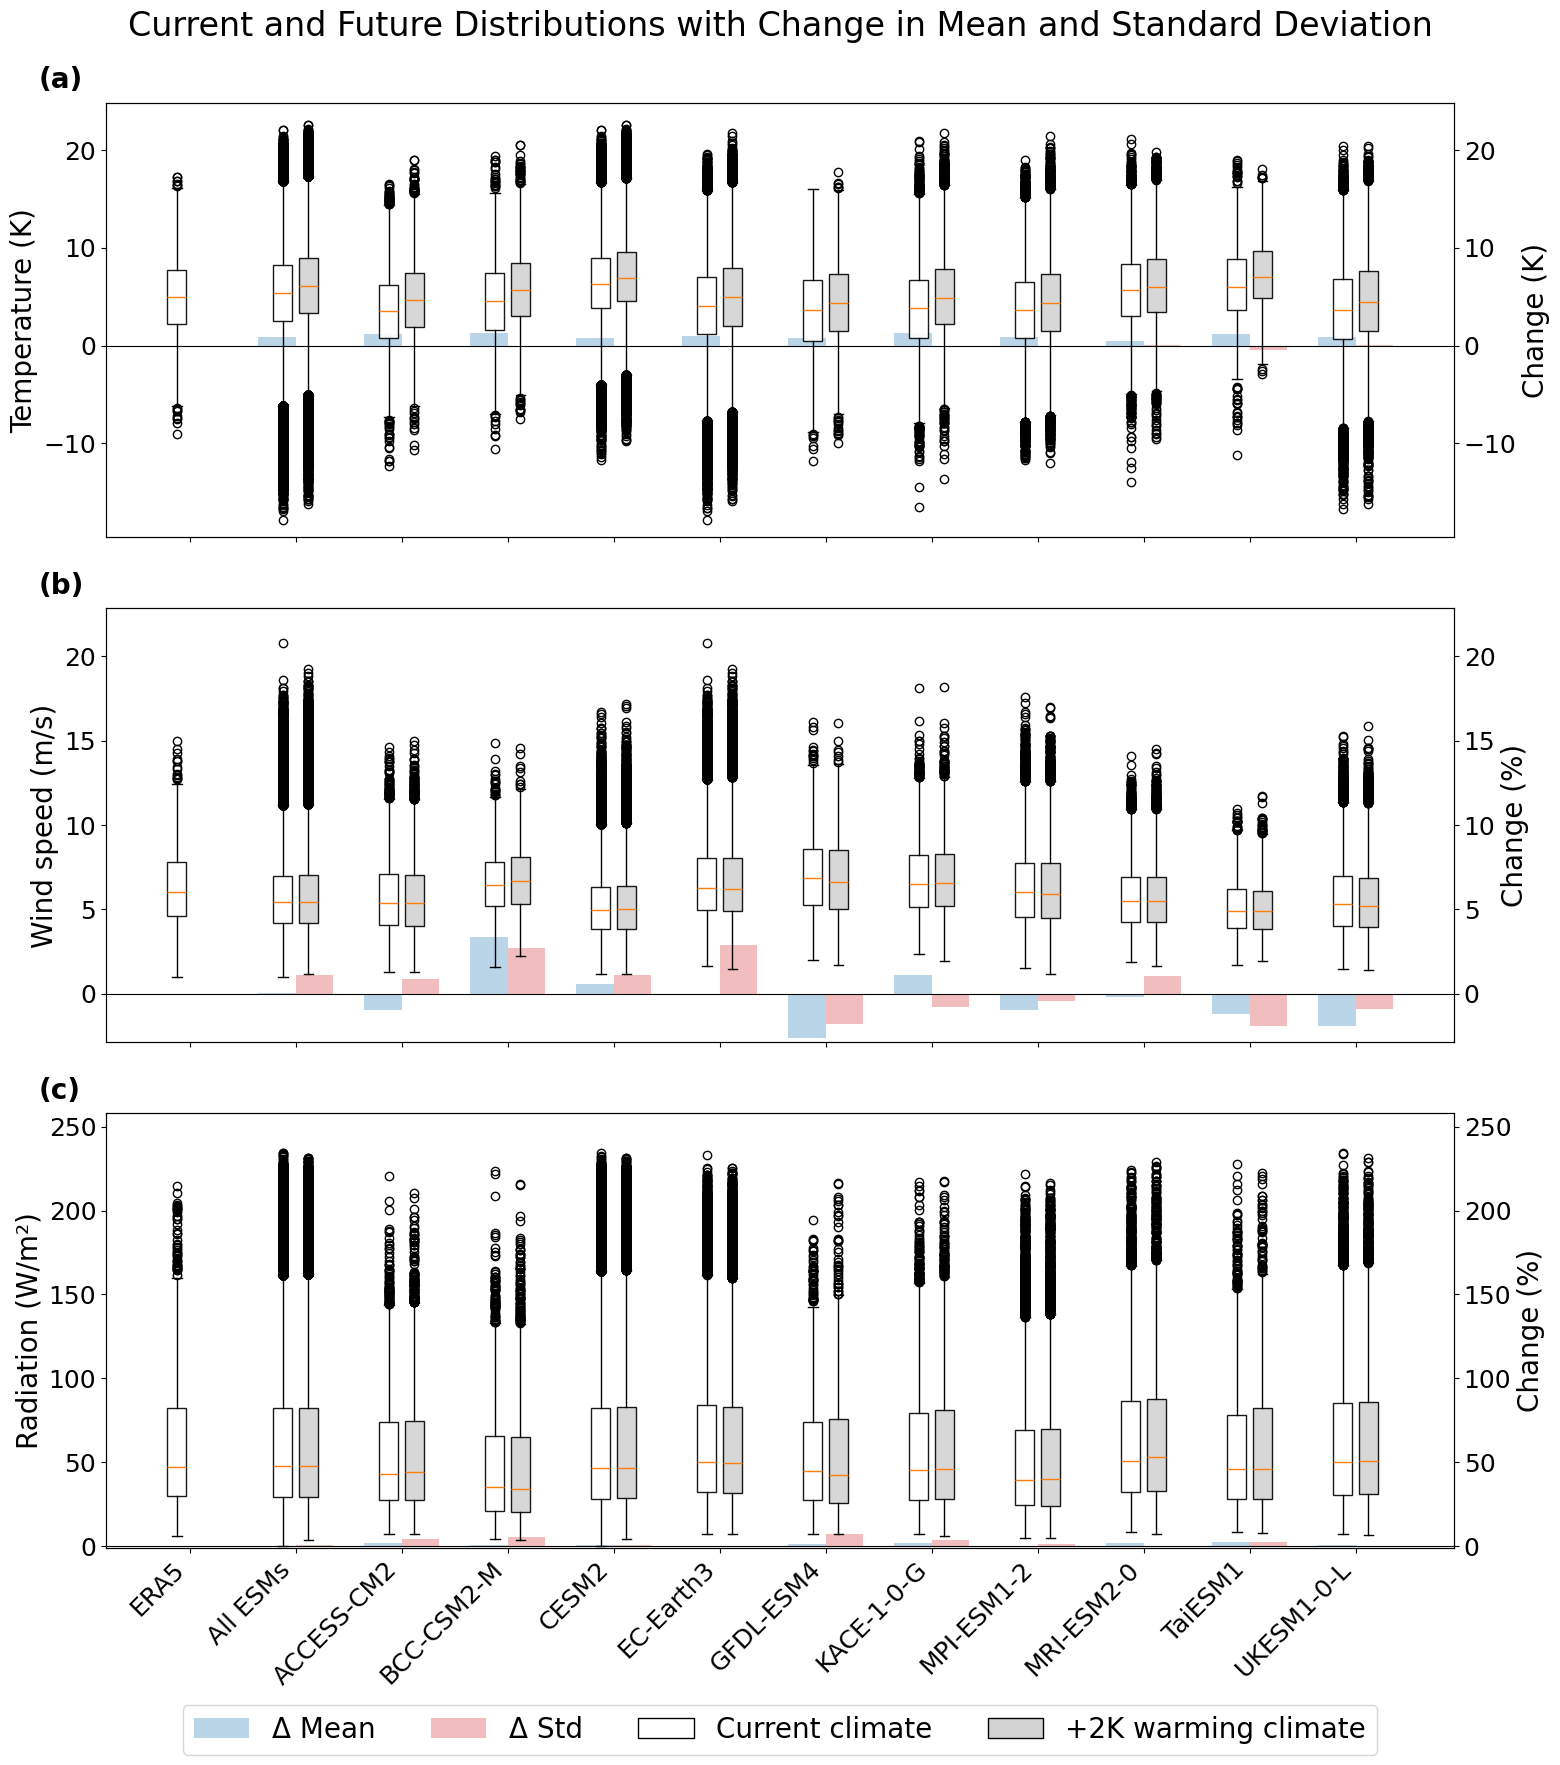

In [5]:
mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
})
# import warnings
# warnings.filterwarnings('ignore')
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

for ax_box, (variable_name, (esm_ds_cur, esm_ds_fut)), panel in zip(
    axes, datasets.items(), panel_labels
):
    cur_dict, fut_dict, summary_df = build_dicts_and_summary(
        esm_ds_cur, esm_ds_fut, variable_name
    )

    esms        = summary_df['ESM'].values
    if variable_name != 'tas':
        print(f"Variable: {variable_name}")
        delta_mean  = summary_df['Delta Mean (%)'].values
        delta_Std   = summary_df['Delta Std (%)'].values
    else:
        delta_mean  = summary_df['Delta Mean'].values
        delta_Std   = summary_df['Delta Std'].values
    n           = len(esms)
    x           = np.arange(n)

    current_data = [cur_dict[k] for k in esms]
    future_data  = [fut_dict[k] for k in esms]

    ax_bar = ax_box.twinx()

    # ── Bars ──────────────────────────────────────────────────────────────────
    bar_width = 0.35
    ax_bar.bar(x - bar_width / 2, delta_mean, width=bar_width,
               color='tab:blue', alpha=0.30, label='Δ Mean', zorder=1)
    ax_bar.bar(x + bar_width / 2, delta_Std,  width=bar_width,
               color='tab:red',  alpha=0.30, label='Δ Std',  zorder=1)

    # ── Boxplots ──────────────────────────────────────────────────────────────
    offset = 0.12
    bp1 = ax_box.boxplot(current_data, positions=x - offset, widths=0.18,
                         patch_artist=True, manage_ticks=False,
                         showfliers=True, zorder=3)
    bp2 = ax_box.boxplot(future_data,  positions=x + offset, widths=0.18,
                         patch_artist=True, manage_ticks=False,
                         showfliers=True, zorder=3)

    for box in bp1['boxes']:
        box.set(facecolor='white',     edgecolor='black', alpha=0.9)
    for box in bp2['boxes']:
        box.set(facecolor='lightgray', edgecolor='black', alpha=0.9)

    # ── Axis limits (shared scale so bars and boxes are comparable) ───────────
    all_vals = np.concatenate([np.concatenate(current_data),
                               np.concatenate(future_data)])
    vmin = np.nanmin(np.concatenate([all_vals, delta_mean, delta_Std]))
    vmax = np.nanmax(np.concatenate([np.abs(all_vals), np.abs(delta_mean), np.abs(delta_Std)]))
    ax_box.set_ylim(1.1 * vmin, 1.1 * vmax)
    ax_bar.set_ylim(1.1 * vmin, 1.1 * vmax)

    ax_box.axhline(0, color='black', linewidth=0.8, zorder=2)

    # ── Labels ────────────────────────────────────────────────────────────────
    ax_box.set_ylabel(var_labels[variable_name])
    if variable_name != 'tas':
        ax_bar.set_ylabel('Change (%)')
    else:
        ax_bar.set_ylabel('Change (K)')
    
    if variable_name == 'rsds':
        ax_box.set_xticks(x)
        ax_box.set_xticklabels(esms, rotation=45, ha='right')
    else:
        ax_box.set_xticks(x)
        ax_box.set_xticklabels("", rotation=45, ha='right')

    # ── Z-order so boxplots sit above bars ────────────────────────────────────
    ax_box.set_zorder(2)
    ax_bar.set_zorder(1)
    ax_box.patch.set_alpha(0)

    # ── Panel label & legend ──────────────────────────────────────────────────
    ax_box.text(-0.05, 1.02, panel, transform=ax_box.transAxes,
                fontsize=20, fontweight='bold', va='bottom')

    legend_elements = [
        Patch(facecolor='tab:blue', alpha=0.30, label='Δ Mean'),
        Patch(facecolor='tab:red',  alpha=0.30, label='Δ Std'),
        Patch(facecolor='white',     edgecolor='black', label='Current climate'),
        Patch(facecolor='lightgray', edgecolor='black', label='+2K warming climate'),
    ]
    if variable_name == 'rsds':
        ax_box.legend(handles=legend_elements, ncol=4, loc='center', bbox_to_anchor=(0.5, -0.42), bbox_transform=ax_box.transAxes)

plt.suptitle('Current and Future Distributions with Change in Mean and Standard Deviation', y=0.98)
plt.tight_layout()
# plt.savefig('/home/onennecke/Code/Figures/vars_dist_comp.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_801956/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)
/tmp/ipykernel_801956/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


Variable: sfcWind


/tmp/ipykernel_801956/407562558.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)


Variable: rsds


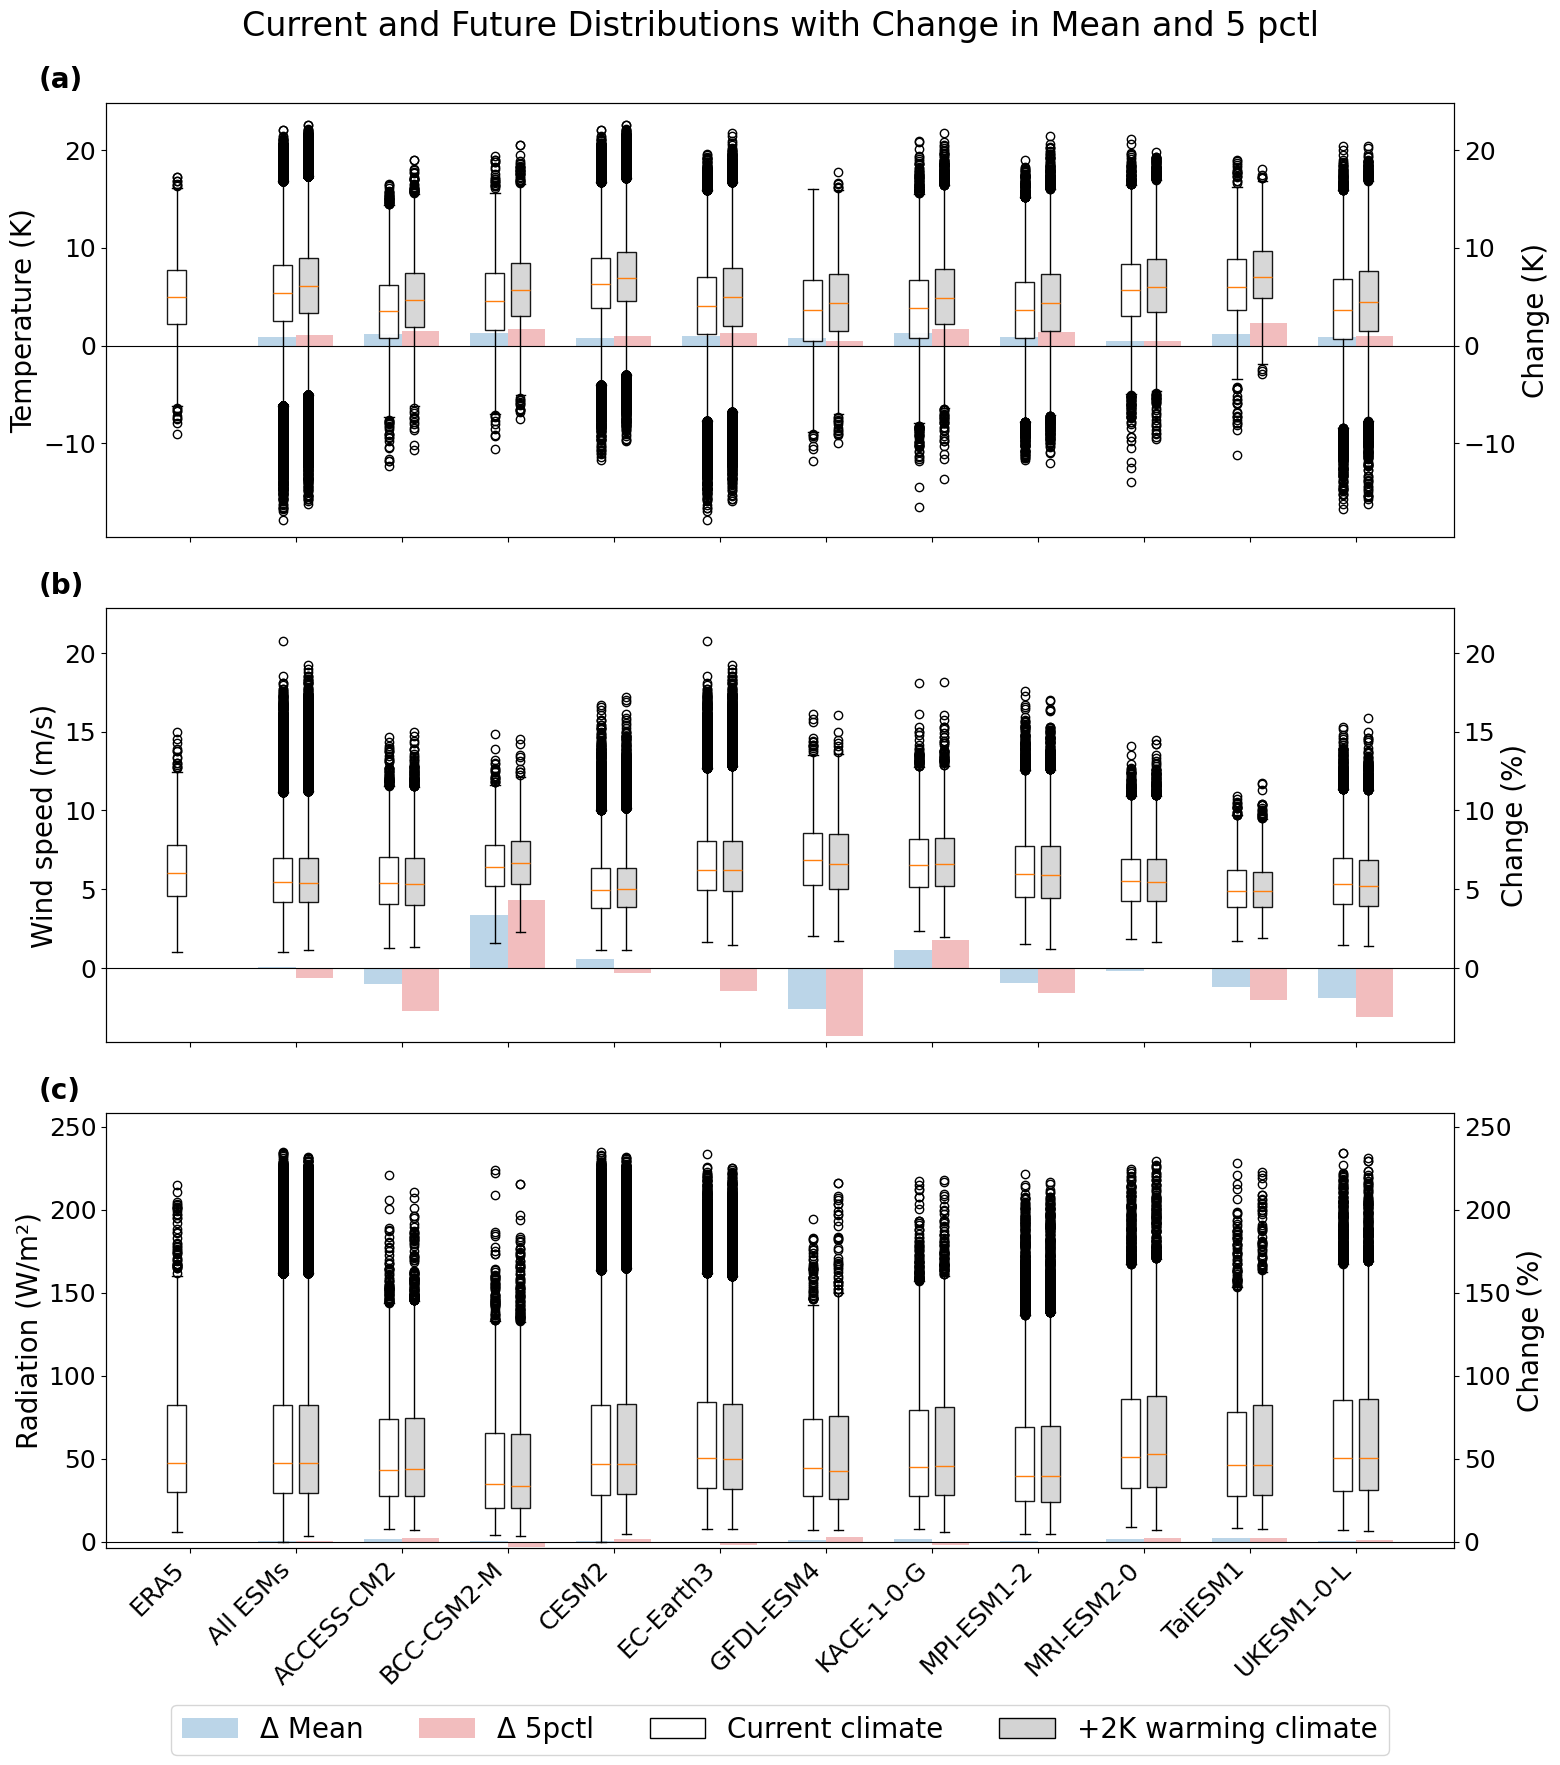

In [9]:
mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
})
# import warnings
# warnings.filterwarnings('ignore')
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

for ax_box, (variable_name, (esm_ds_cur, esm_ds_fut)), panel in zip(
    axes, datasets.items(), panel_labels
):
    cur_dict, fut_dict, summary_df = build_dicts_and_summary(
        esm_ds_cur, esm_ds_fut, variable_name
    )

    esms        = summary_df['ESM'].values
    if variable_name != 'tas':
        print(f"Variable: {variable_name}")
        delta_mean  = summary_df['Delta Mean (%)'].values
        delta_5pctl   = summary_df['Delta 5pctl (%)'].values
    else:
        delta_mean  = summary_df['Delta Mean'].values
        delta_5pctl   = summary_df['Delta 5pctl'].values
    n           = len(esms)
    x           = np.arange(n)

    current_data = [cur_dict[k] for k in esms]
    future_data  = [fut_dict[k] for k in esms]

    ax_bar = ax_box.twinx()

    # ── Bars ──────────────────────────────────────────────────────────────────
    bar_width = 0.35
    ax_bar.bar(x - bar_width / 2, delta_mean, width=bar_width,
               color='tab:blue', alpha=0.30, label='Δ Mean', zorder=1)
    ax_bar.bar(x + bar_width / 2, delta_5pctl,  width=bar_width,
               color='tab:red',  alpha=0.30, label='Δ 5pctl',  zorder=1)

    # ── Boxplots ──────────────────────────────────────────────────────────────
    offset = 0.12
    bp1 = ax_box.boxplot(current_data, positions=x - offset, widths=0.18,
                         patch_artist=True, manage_ticks=False,
                         showfliers=True, zorder=3)
    bp2 = ax_box.boxplot(future_data,  positions=x + offset, widths=0.18,
                         patch_artist=True, manage_ticks=False,
                         showfliers=True, zorder=3)

    for box in bp1['boxes']:
        box.set(facecolor='white',     edgecolor='black', alpha=0.9)
    for box in bp2['boxes']:
        box.set(facecolor='lightgray', edgecolor='black', alpha=0.9)

    # ── Axis limits (shared scale so bars and boxes are comparable) ───────────
    all_vals = np.concatenate([np.concatenate(current_data),
                               np.concatenate(future_data)])
    vmin = np.nanmin(np.concatenate([all_vals, delta_mean, delta_5pctl]))
    vmax = np.nanmax(np.concatenate([np.abs(all_vals), np.abs(delta_mean), np.abs(delta_5pctl)]))
    ax_box.set_ylim(1.1 * vmin, 1.1 * vmax)
    ax_bar.set_ylim(1.1 * vmin, 1.1 * vmax)

    ax_box.axhline(0, color='black', linewidth=0.8, zorder=2)

    # ── Labels ────────────────────────────────────────────────────────────────
    ax_box.set_ylabel(var_labels[variable_name])
    if variable_name != 'tas':
        ax_bar.set_ylabel('Change (%)')
    else:
        ax_bar.set_ylabel('Change (K)')
    
    if variable_name == 'rsds':
        ax_box.set_xticks(x)
        ax_box.set_xticklabels(esms, rotation=45, ha='right')
    else:
        ax_box.set_xticks(x)
        ax_box.set_xticklabels("", rotation=45, ha='right')

    # ── Z-order so boxplots sit above bars ────────────────────────────────────
    ax_box.set_zorder(2)
    ax_bar.set_zorder(1)
    ax_box.patch.set_alpha(0)

    # ── Panel label & legend ──────────────────────────────────────────────────
    ax_box.text(-0.05, 1.02, panel, transform=ax_box.transAxes,
                fontsize=20, fontweight='bold', va='bottom')

    legend_elements = [
        Patch(facecolor='tab:blue', alpha=0.30, label='Δ Mean'),
        Patch(facecolor='tab:red',  alpha=0.30, label='Δ 5pctl'),
        Patch(facecolor='white',     edgecolor='black', label='Current climate'),
        Patch(facecolor='lightgray', edgecolor='black', label='+2K warming climate'),
    ]
    if variable_name == 'rsds':
        ax_box.legend(handles=legend_elements, ncol=4, loc='center', bbox_to_anchor=(0.5, -0.42), bbox_transform=ax_box.transAxes)

plt.suptitle('Current and Future Distributions with Change in Mean and 5 pctl', y=0.98)
plt.tight_layout()
# plt.savefig('/home/onennecke/Code/Figures/vars_dist_comp.png', dpi=300, bbox_inches='tight')
plt.show()
